# HAM10000 - Clasificador de Lesiones Cutáneas con ResNet50
**Dataset:** HAM10000 (Human Against Machine with 10000 training images)  
**Modelo:** ResNet50 preentrenado con ImageNet + Fine-tuning  
**Framework:** TensorFlow / Keras

## Clases del Dataset
| Abreviatura | Descripción |
|---|---|
| `akiec` | Queratosis actínica / carcinoma intraepitelial |
| `bcc` | Carcinoma basocelular |
| `bkl` | Lesiones benignas tipo queratosis |
| `df` | Dermatofibroma |
| `mel` | Melanoma |
| `nv` | Nevos melanocíticos |
| `vasc` | Lesiones vasculares |


**Estructura esperada del dataset:**
```
HAM10000/
├── HAM10000_images_part_1/   ← imágenes .jpg
├── HAM10000_images_part_2/   ← imágenes .jpg
└── HAM10000_metadata.csv     ← metadatos con etiquetas
```

## 1. Instalación de Dependencias

In [ ]:
#!pip install tensorflow pandas numpy matplotlib scikit-learn seaborn Pillow tqdm -q

## 2. Importaciones

In [1]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from glob import glob

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

print(f'TensorFlow version: {tf.__version__}')
print(f'GPUs disponibles: {len(tf.config.list_physical_devices("GPU"))}')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

2026-06-03 13:31:21.921270: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-03 13:31:22.258642: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-03 13:31:22.258824: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-03 13:31:22.316590: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-03 13:31:22.430857: I tensorflow/core/platform/cpu_feature_guar

TensorFlow version: 2.15.0
GPUs disponibles: 1


2026-06-03 13:31:27.505021: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-03 13:31:27.716432: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-03 13:31:27.716520: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-03 13:31:27.716529: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 3. Configuración e Hiperparámetros

In [2]:
# ─────────────────────────────────────────────────────────────────
# RUTAS DEL DATASET
# Descarga desde: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
# Descomprime y ajusta BASE_DIR a la carpeta raíz del dataset.
# ─────────────────────────────────────────────────────────────────
BASE_DIR        = './ham10000'
IMG_DIR_1       = os.path.join(BASE_DIR, 'HAM10000_images_part_1')
IMG_DIR_2       = os.path.join(BASE_DIR, 'HAM10000_images_part_2')
METADATA_PATH   = os.path.join(BASE_DIR, 'HAM10000_metadata.csv')

# Hiperparámetros
IMG_SIZE         = (224, 224)
BATCH_SIZE       = 32
EPOCHS_FROZEN    = 15          # Fase 1: base congelada
EPOCHS_FINETUNE  = 25          # Fase 2: fine-tuning
LR_FROZEN        = 1e-3
LR_FINETUNE      = 1e-5
FINETUNE_FROM    = 140         # Descongelar desde esta capa (de ~175 en total)

# Clases
CLASS_NAMES  = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
CLASS_LABELS = {
    'akiec': 'Queratosis Actínica',
    'bcc':   'Carcinoma Basocelular',
    'bkl':   'Queratosis Benigna',
    'df':    'Dermatofibroma',
    'mel':   'Melanoma',
    'nv':    'Nevo Melanocítico',
    'vasc':  'Lesión Vascular'
}
NUM_CLASSES = len(CLASS_NAMES)
print(f'Clases ({NUM_CLASSES}): {CLASS_NAMES}')

Clases (7): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


## 4. Carga y Exploración del Dataset

In [3]:
df = pd.read_csv(METADATA_PATH)
print(f'Total de registros: {len(df)}')
print(f'Columnas: {df.columns.tolist()}')
df.head()

Total de registros: 10015
Columnas: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [4]:
# Construir mapa image_id → ruta de archivo
all_images = {}
for folder in [IMG_DIR_1, IMG_DIR_2]:
    for path in glob(os.path.join(folder, '*.jpg')):
        img_id = os.path.splitext(os.path.basename(path))[0]
        all_images[img_id] = path

print(f'Imágenes encontradas en disco: {len(all_images)}')
df['path'] = df['image_id'].map(all_images)
df = df.dropna(subset=['path'])
print(f'Imágenes con ruta válida:      {len(df)}')

Imágenes encontradas en disco: 10015
Imágenes con ruta válida:      10015


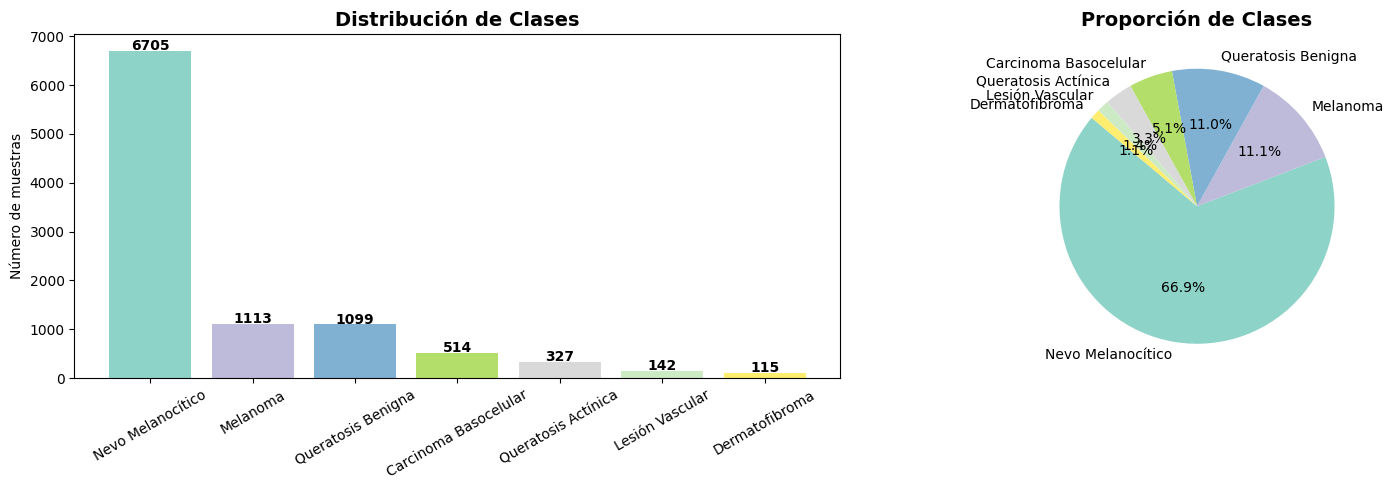

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
# Distribución de clases
class_counts = df['dx'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bars = axes[0].bar([CLASS_LABELS[c] for c in class_counts.index],
                   class_counts.values, color=colors)
axes[0].set_title('Distribución de Clases', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Número de muestras')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', fontweight='bold')

axes[1].pie(class_counts.values,
            labels=[CLASS_LABELS[c] for c in class_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=140)
axes[1].set_title('Proporción de Clases', fontsize=14, fontweight='bold')

plt.tight_layout()
#plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(class_counts)

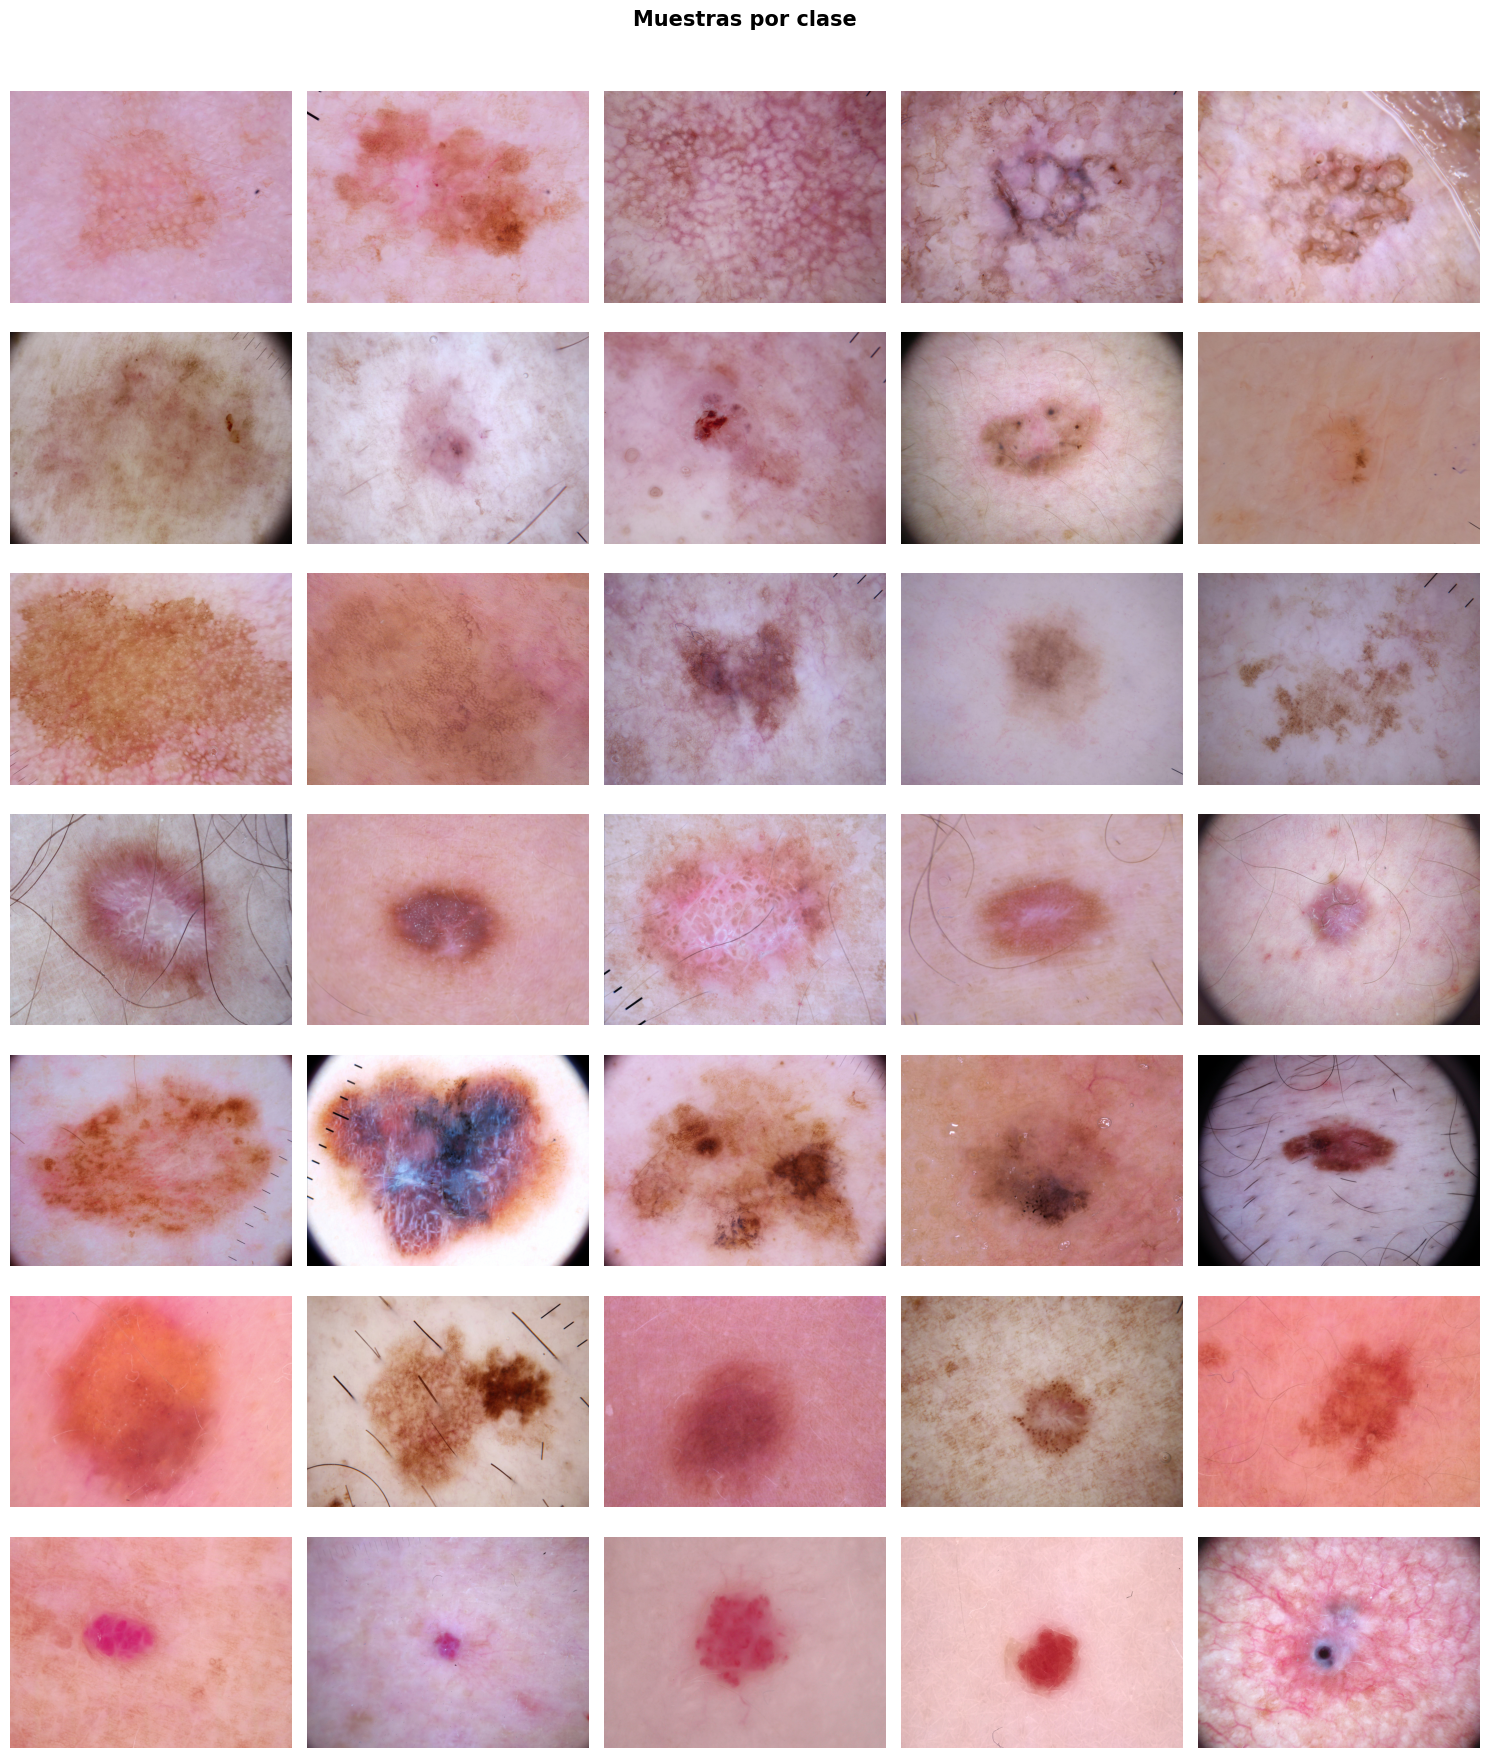

In [ ]:
# Visualizar 5 ejemplos por clase
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(15, NUM_CLASSES * 2.5))
fig.suptitle('Muestras por clase', fontsize=15, fontweight='bold', y=1.01)

for i, cls in enumerate(CLASS_NAMES):
    samples = df[df['dx'] == cls].sample(5, random_state=SEED)
    for j, (_, row) in enumerate(samples.iterrows()):
        axes[i, j].imshow(Image.open(row['path']))
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(CLASS_LABELS[cls], fontsize=9, fontweight='bold')

plt.tight_layout()
#plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. División del Dataset y Generadores de Datos

In [7]:
# División estratificada: 70% train / 15% val / 15% test
df['label']     = df['dx'].map({cls: i for i, cls in enumerate(CLASS_NAMES)})
df['label_str'] = df['dx']

df_trainval, df_test = train_test_split(
    df, test_size=0.15, stratify=df['dx'], random_state=SEED)

df_train, df_val = train_test_split(
    df_trainval, test_size=0.1765, stratify=df_trainval['dx'], random_state=SEED)

print(f'Train:      {len(df_train):>5}  ({len(df_train)/len(df)*100:.1f}%)')
print(f'Validación: {len(df_val):>5}  ({len(df_val)/len(df)*100:.1f}%)')
print(f'Test:       {len(df_test):>5}  ({len(df_test)/len(df)*100:.1f}%)')

Train:       7009  (70.0%)
Validación:  1503  (15.0%)
Test:        1503  (15.0%)


In [8]:
# Pesos de clase para manejar el desbalance
cw_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=df_train['label'].values
)
class_weights = {i: w for i, w in enumerate(cw_array)}

print('Pesos por clase:')
for i, cls in enumerate(CLASS_NAMES):
    print(f'  [{i}] {CLASS_LABELS[cls]:<30} → {class_weights[i]:.4f}')

Pesos por clase:
  [0] Queratosis Actínica            → 4.3724
  [1] Carcinoma Basocelular          → 2.7813
  [2] Queratosis Benigna             → 1.3021
  [3] Dermatofibroma                 → 12.5161
  [4] Melanoma                       → 1.2853
  [5] Nevo Melanocítico              → 0.2134
  [6] Lesión Vascular                → 10.1140


In [9]:
preprocess_input = tf.keras.applications.resnet50.preprocess_input

# Generador de entrenamiento con data augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Sin augmentation para validación y test
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

def make_generator(datagen, df_split, shuffle=False):
    return datagen.flow_from_dataframe(
        dataframe=df_split,
        x_col='path',
        y_col='label_str',
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=CLASS_NAMES,
        shuffle=shuffle,
        seed=SEED
    )

train_gen = make_generator(train_datagen, df_train, shuffle=True)
val_gen   = make_generator(val_test_datagen, df_val)
test_gen  = make_generator(val_test_datagen, df_test)

print(f'Steps/epoch train: {len(train_gen)}')
print(f'Steps/epoch val:   {len(val_gen)}')
print(f'Steps test:        {len(test_gen)}')

Found 7009 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.
Steps/epoch train: 220
Steps/epoch val:   47
Steps test:        47


## 6. Construcción del Modelo ResNet50

In [10]:
def build_model(num_classes, input_shape=(224, 224, 3), freeze_base=True):
    """
    ResNet50 preentrenada con ImageNet + cabeza de clasificación personalizada.
    
    Arquitectura:
      Input → ResNet50 (base) → GlobalAvgPool → BN → Dense(512,relu)
              → Dropout(0.5) → Dense(256,relu) → Dropout(0.3) → Dense(N,softmax)
    """
    base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = not freeze_base

    inputs = keras.Input(shape=input_shape, name='input_image')
    x = base(inputs, training=False)   # BN de la base en modo inferencia
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_top')(x)
    x = layers.Dense(512, activation='relu', name='fc1')(x)
    x = layers.Dropout(0.5, name='drop1')(x)
    x = layers.Dense(256, activation='relu', name='fc2')(x)
    x = layers.Dropout(0.3, name='drop2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    return Model(inputs, outputs, name='HAM10000_ResNet50'), base


model, base_model = build_model(NUM_CLASSES, input_shape=IMG_SIZE + (3,), freeze_base=True)

model.compile(
    optimizer=Adam(learning_rate=LR_FROZEN),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print(f'Capas base ResNet50:        {len(base_model.layers)}')
print(f'Parámetros totales:         {model.count_params():,}')
print(f'Parámetros entrenables:     {sum(np.prod(v.shape) for v in model.trainable_variables):,}')
model.summary()

2026-06-03 13:31:31.723404: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-03 13:31:31.723494: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-03 13:31:31.723531: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-03 13:31:31.723539: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-06-03 13:31:32.936041: I external/lo

Capas base ResNet50:        175
Parámetros totales:         24,778,119
Parámetros entrenables:     1,186,311
Model: "HAM10000_ResNet50"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_image (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 gap (GlobalAveragePooling2  (None, 2048)              0         
 D)                                                              
                                                                 
 bn_top (BatchNormalization  (None, 2048)              8192      
 )                                                               
                                                                 
 fc1 (Dense)                 (None, 512)               1049088   
      

## 7. Fase 1 - Entrenamiento con Base Congelada

In [11]:
callbacks_p1 = [
    ModelCheckpoint('best_phase1.keras', monitor='val_auc', mode='max',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_auc', mode='max', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                      min_lr=1e-7, verbose=1)
]

print('=' * 55)
print('FASE 1: Base ResNet50 CONGELADA')
print('=' * 55)

history1 = model.fit(
    train_gen,
    epochs=EPOCHS_FROZEN,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks_p1,
    verbose=1
)

FASE 1: Base ResNet50 CONGELADA
Epoch 1/15


2026-06-03 13:31:38.504189: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2026-06-03 13:31:38.560343: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-06-03 13:31:38.580525: W external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:225] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 12.0
2026-06-03 13:31:38.580595: W external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:228] Used ptxas at /home/jesus/repos/TFM/.venv/lib/python3.11/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc/bin/ptxas
2026-06-03 13:31:38.580673: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-06-03 13:31:38.682511: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such

  1/220 [..............................] - ETA: 31:07 - loss: 1.9464 - accuracy: 0.0625 - auc: 0.2747 - precision: 0.0000e+00 - recall: 0.0000e+00

2026-06-03 13:31:43.770640: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


220/220 [==============================] - ETA: 0s - loss: 2.1524 - accuracy: 0.4186 - auc: 0.7830 - precision: 0.4902 - recall: 0.3531
Epoch 1: val_auc improved from -inf to 0.88498, saving model to best_phase1.keras
220/220 [==============================] - 82s 334ms/step - loss: 2.1524 - accuracy: 0.4186 - auc: 0.7830 - precision: 0.4902 - recall: 0.3531 - val_loss: 1.1791 - val_accuracy: 0.5216 - val_auc: 0.8850 - val_precision: 0.6888 - val_recall: 0.3446 - lr: 0.0010
Epoch 2/15
220/220 [==============================] - ETA: 0s - loss: 1.5138 - accuracy: 0.4855 - auc: 0.8331 - precision: 0.5858 - recall: 0.3868
Epoch 2: val_auc did not improve from 0.88498
220/220 [==============================] - 65s 294ms/step - loss: 1.5138 - accuracy: 0.4855 - auc: 0.8331 - precision: 0.5858 - recall: 0.3868 - val_loss: 1.4155 - val_accuracy: 0.4045 - val_auc: 0.8368 - val_precision: 0.4580 - val_recall: 0.2468 - lr: 0.0010
Epoch 3/15
220/220 [==============================] - ETA: 0s - los

## 8. Fase 2 - Fine-Tuning

In [12]:
print('=' * 55)
print(f'FASE 2: Descongelando capas > {FINETUNE_FROM} de ResNet50')
print('=' * 55)

base_model.trainable = True

# Congelar las capas inferiores
for layer in base_model.layers[:FINETUNE_FROM]:
    layer.trainable = False

# BatchNorm siempre en modo inferencia para evitar inestabilidad
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(f'Parámetros entrenables: {sum(np.prod(v.shape) for v in model.trainable_variables):,}')

model.compile(
    optimizer=Adam(learning_rate=LR_FINETUNE),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks_p2 = [
    ModelCheckpoint('best_finetune.keras', monitor='val_auc', mode='max',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_auc', mode='max', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4,
                      min_lr=1e-8, verbose=1)
]

history2 = model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks_p2,
    verbose=1
)

FASE 2: Descongelando capas > 140 de ResNet50
Parámetros entrenables: 16,139,783
Epoch 1/25
220/220 [==============================] - ETA: 0s - loss: 0.8861 - accuracy: 0.6423 - auc: 0.9304 - precision: 0.7331 - recall: 0.5429
Epoch 1: val_auc improved from -inf to 0.93969, saving model to best_finetune.keras
220/220 [==============================] - 71s 292ms/step - loss: 0.8861 - accuracy: 0.6423 - auc: 0.9304 - precision: 0.7331 - recall: 0.5429 - val_loss: 0.8488 - val_accuracy: 0.6507 - val_auc: 0.9397 - val_precision: 0.7768 - val_recall: 0.5116 - lr: 1.0000e-05
Epoch 2/25
220/220 [==============================] - ETA: 0s - loss: 0.7842 - accuracy: 0.6504 - auc: 0.9335 - precision: 0.7606 - recall: 0.5580
Epoch 2: val_auc improved from 0.93969 to 0.94093, saving model to best_finetune.keras
220/220 [==============================] - 68s 307ms/step - loss: 0.7842 - accuracy: 0.6504 - auc: 0.9335 - precision: 0.7606 - recall: 0.5580 - val_loss: 0.8420 - val_accuracy: 0.6440 - va

## 9. Visualización del Entrenamiento

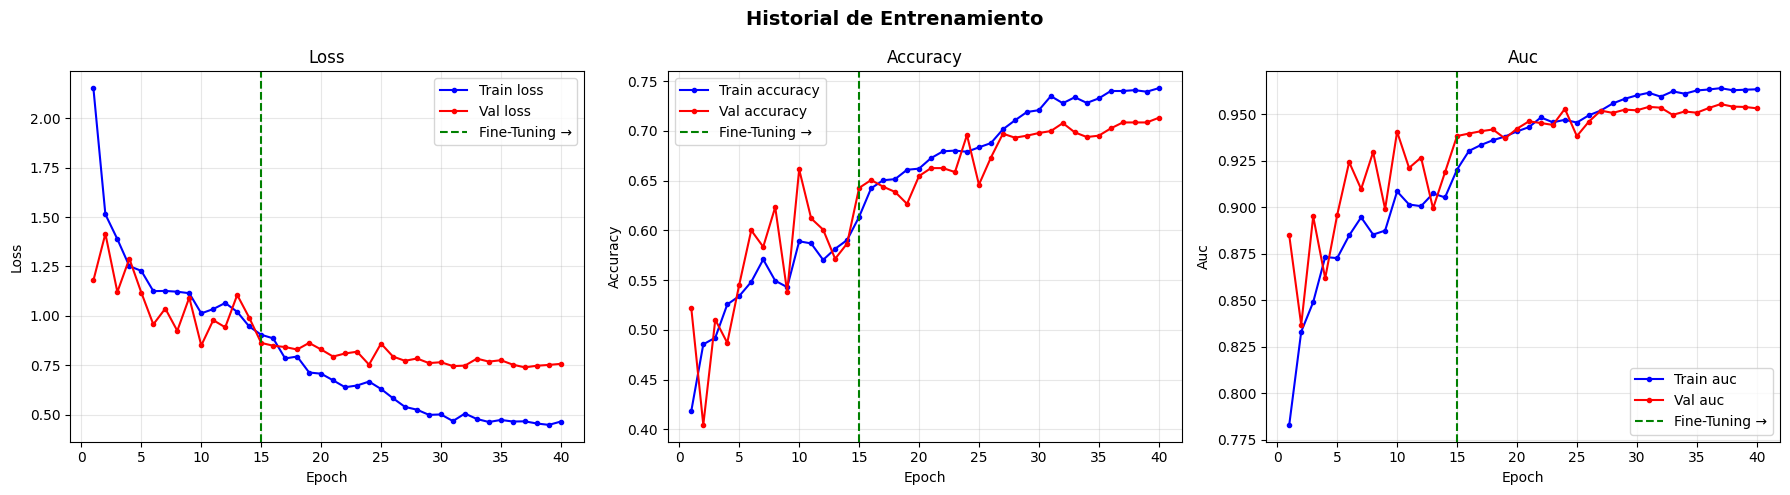

In [13]:
def plot_history(h1, h2, metrics=('loss', 'accuracy', 'auc')):
    combined = {k: h1.history[k] + h2.history[k] for k in h1.history}
    boundary = len(h1.history['loss'])
    x = range(1, len(combined['loss']) + 1)

    fig, axes = plt.subplots(1, len(metrics), figsize=(6 * len(metrics), 5))
    fig.suptitle('Historial de Entrenamiento', fontsize=14, fontweight='bold')

    for ax, m in zip(axes, metrics):
        ax.plot(x, combined[m],           'b-o', ms=3, label=f'Train {m}')
        ax.plot(x, combined[f'val_{m}'],  'r-o', ms=3, label=f'Val {m}')
        ax.axvline(boundary, color='green', ls='--', lw=1.5, label='Fine-Tuning →')
        ax.set_xlabel('Epoch'); ax.set_ylabel(m.capitalize())
        ax.set_title(m.capitalize()); ax.legend(); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    #plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history1, history2)

## 10. Evaluación en el Conjunto de Test

In [14]:
best_model = keras.models.load_model('best_finetune.keras')

print('Evaluando en test...')
test_results = best_model.evaluate(test_gen, verbose=1)

print('\n' + '='*50)
print('MÉTRICAS EN TEST')
print('='*50)
for name, val in zip(best_model.metrics_names, test_results):
    print(f'  {name:<15}: {val:.4f}')

Evaluando en test...
47/47 [==============================] - 8s 145ms/step - loss: 0.7534 - accuracy: 0.6906 - auc: 0.9530 - precision: 0.7613 - recall: 0.6301

MÉTRICAS EN TEST
  loss           : 0.7534
  accuracy       : 0.6906
  auc            : 0.9530
  precision      : 0.7613
  recall         : 0.6301


In [15]:
# Predicciones
test_gen.reset()
y_proba = best_model.predict(test_gen, verbose=1)
y_pred  = np.argmax(y_proba, axis=1)
y_true  = test_gen.classes

print('\nREPORTE DE CLASIFICACIÓN')
print('='*70)
print(classification_report(
    y_true, y_pred,
    target_names=[CLASS_LABELS[c] for c in CLASS_NAMES]
))

47/47 [==============================] - 6s 106ms/step

REPORTE DE CLASIFICACIÓN
                       precision    recall  f1-score   support

  Queratosis Actínica       0.70      0.53      0.60        49
Carcinoma Basocelular       0.74      0.58      0.65        77
   Queratosis Benigna       0.49      0.80      0.61       165
       Dermatofibroma       0.28      0.65      0.39        17
             Melanoma       0.34      0.75      0.47       167
    Nevo Melanocítico       0.97      0.67      0.80      1006
      Lesión Vascular       0.79      0.86      0.83        22

             accuracy                           0.69      1503
            macro avg       0.62      0.69      0.62      1503
         weighted avg       0.82      0.69      0.72      1503



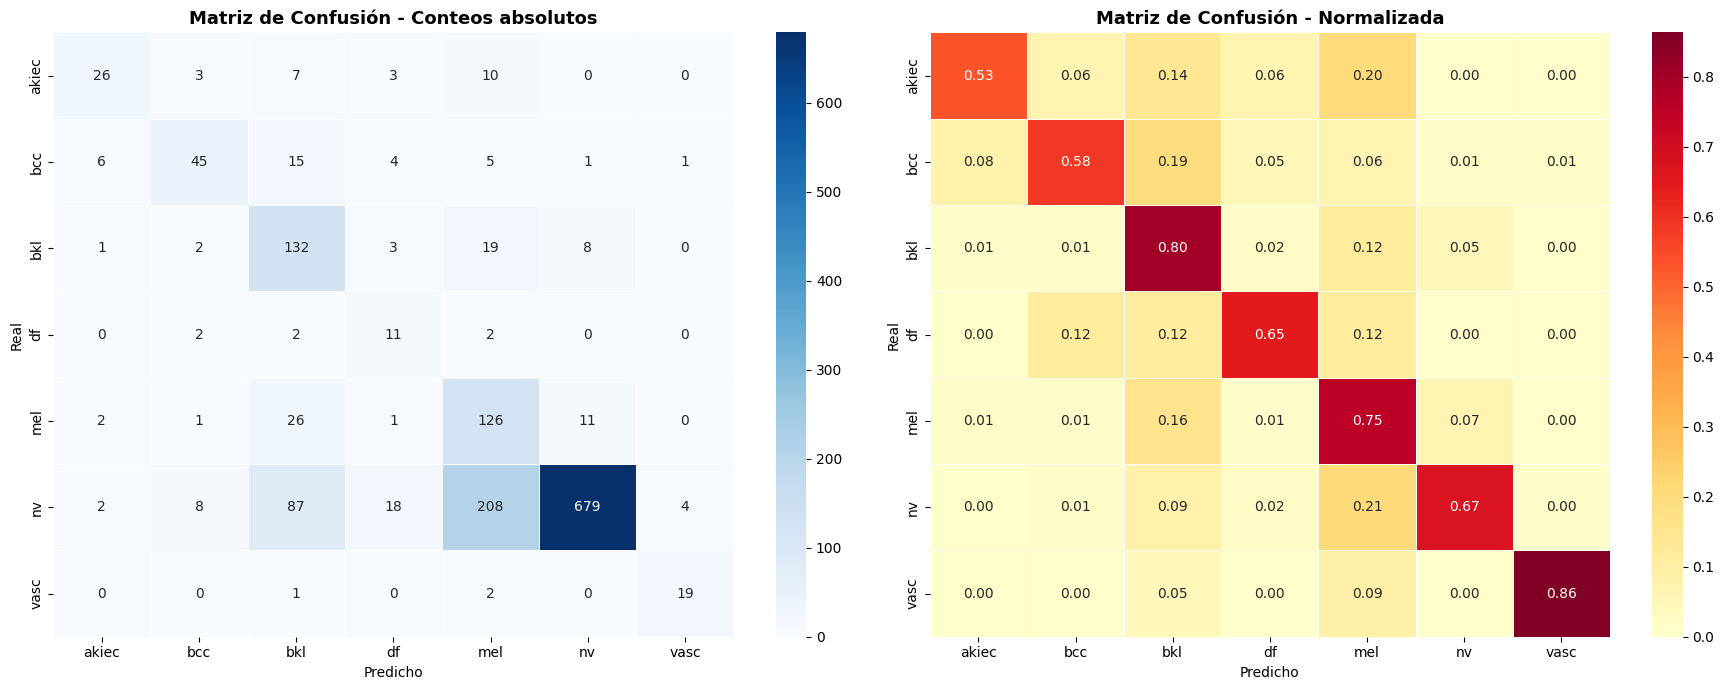

In [16]:
# Matrices de confusión
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2f'],
        ['Conteos absolutos', 'Normalizada']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues' if fmt=='d' else 'YlOrRd',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5)
    ax.set_title(f'Matriz de Confusión - {title}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Real'); ax.set_xlabel('Predicho')

plt.tight_layout()
#plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

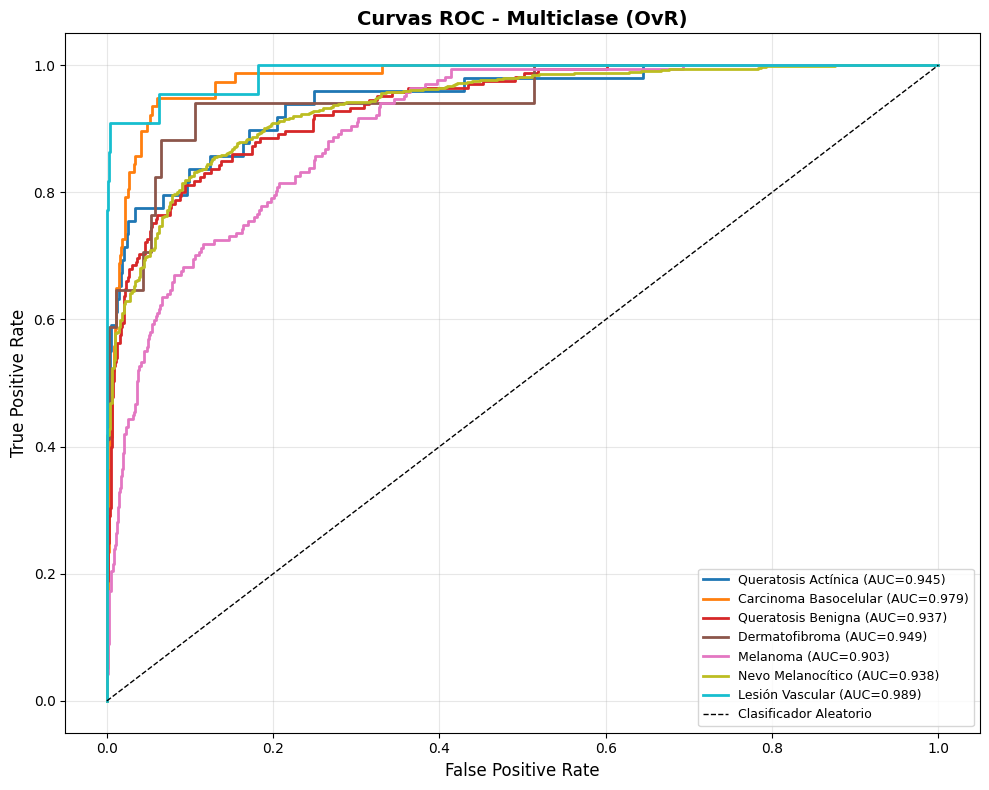


AUC por clase:
  Queratosis Actínica                 AUC = 0.9455
  Carcinoma Basocelular               AUC = 0.9787
  Queratosis Benigna                  AUC = 0.9367
  Dermatofibroma                      AUC = 0.9495
  Melanoma                            AUC = 0.9028
  Nevo Melanocítico                   AUC = 0.9383
  Lesión Vascular                     AUC = 0.9886

  Macro-AUC: 0.9486


In [17]:
# Curvas ROC One-vs-Rest
y_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
colors_roc = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

fig, ax = plt.subplots(figsize=(10, 8))
auc_scores = {}
for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores[cls] = roc_auc
    ax.plot(fpr, tpr, color=col, lw=2,
            label=f'{CLASS_LABELS[cls]} (AUC={roc_auc:.3f})')

ax.plot([0,1],[0,1],'k--',lw=1, label='Clasificador Aleatorio')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Curvas ROC - Multiclase (OvR)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAUC por clase:')
for cls, s in auc_scores.items():
    print(f'  {CLASS_LABELS[cls]:<35} AUC = {s:.4f}')
print(f'\n  Macro-AUC: {np.mean(list(auc_scores.values())):.4f}')

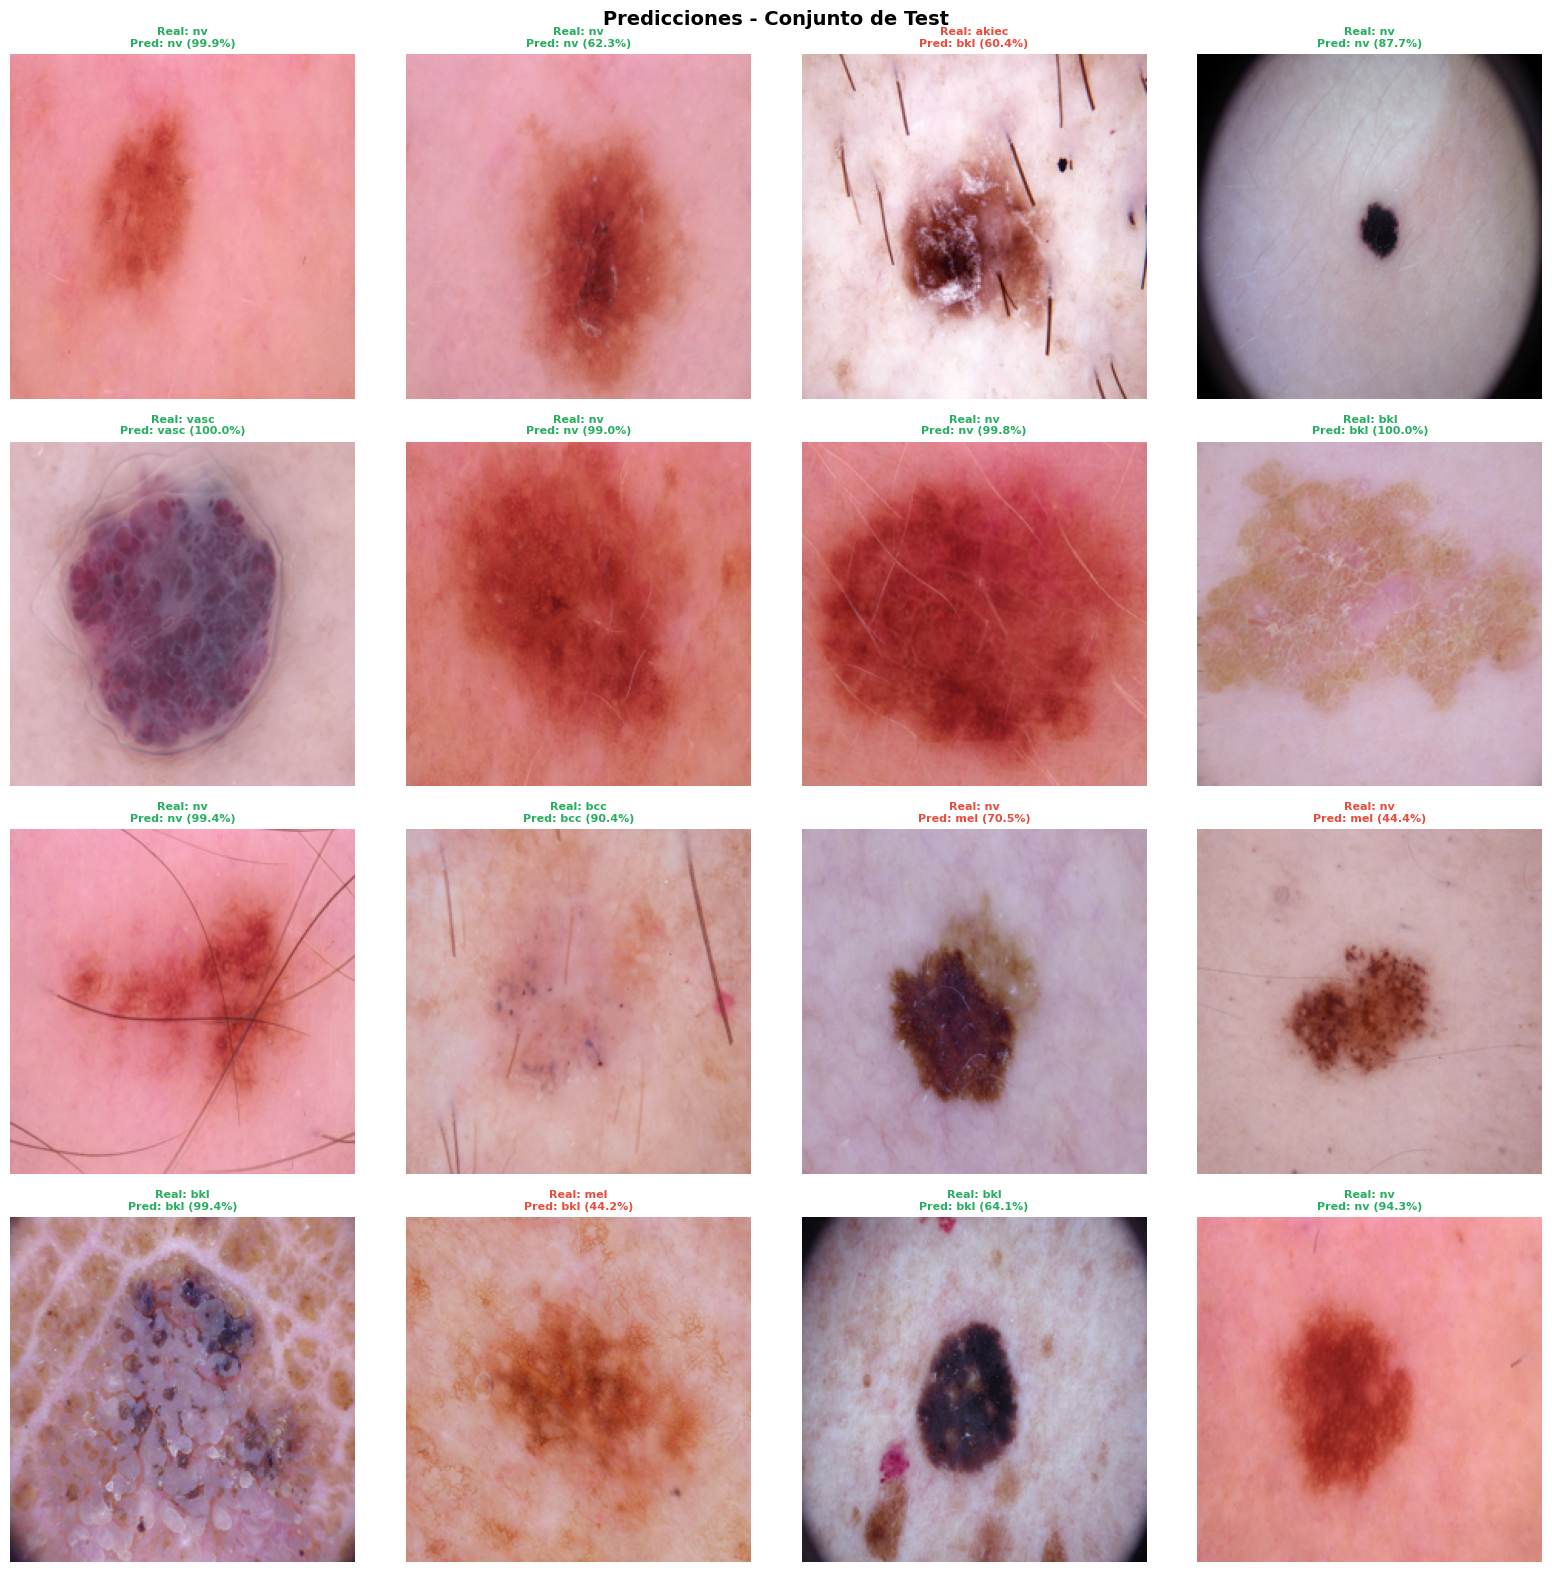

In [18]:
# Visualización de predicciones individuales
test_df_reset = df_test.reset_index(drop=True)
idx = np.random.RandomState(SEED).choice(len(test_df_reset), 16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle('Predicciones - Conjunto de Test', fontsize=14, fontweight='bold')

for ax, i in zip(axes.flatten(), idx):
    img = Image.open(test_df_reset.loc[i, 'path']).resize(IMG_SIZE)
    true_cls = CLASS_NAMES[y_true[i]]
    pred_cls = CLASS_NAMES[y_pred[i]]
    conf     = y_proba[i, y_pred[i]]
    correct  = y_true[i] == y_pred[i]
    color    = '#27AE60' if correct else '#E74C3C'
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Real: {true_cls}\nPred: {pred_cls} ({conf:.1%})',
                 fontsize=8, color=color, fontweight='bold')

plt.tight_layout()
#plt.savefig('predictions_sample.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Guardar el Modelo Final

In [ ]:
#best_model.save('HAM10000_ResNet50_final.keras')
#best_model.save_weights('HAM10000_ResNet50.weights.h5')
print('Modelo guardado: HAM10000_ResNet50_final.keras')
print('Pesos guardados: HAM10000_ResNet50.weights.h5')

print('\n' + '='*55)
print('RESUMEN FINAL')
print('='*55)
print(f'  Epochs Fase 1:   {len(history1.history["loss"])}')
print(f'  Epochs Fase 2:   {len(history2.history["loss"])}')
print(f'  Mejor val_auc P1: {max(history1.history["val_auc"]):.4f}')
print(f'  Mejor val_auc P2: {max(history2.history["val_auc"]):.4f}')
for name, val in zip(best_model.metrics_names, test_results):
    print(f'  Test {name:<12}: {val:.4f}')
print(f'  Macro-AUC OvR:   {np.mean(list(auc_scores.values())):.4f}')

Modelo guardado: HAM10000_ResNet50_final.keras
Pesos guardados: HAM10000_ResNet50.weights.h5

RESUMEN FINAL
  Epochs Fase 1:   15
  Epochs Fase 2:   25
  Mejor val_auc P1: 0.9406
  Mejor val_auc P2: 0.9555
  Test loss        : 0.7534
  Test accuracy    : 0.6906
  Test auc         : 0.9530
  Test precision   : 0.7613
  Test recall      : 0.6301
  Macro-AUC OvR:   0.9486


## 12. Función de Inferencia para Nuevas Imágenes

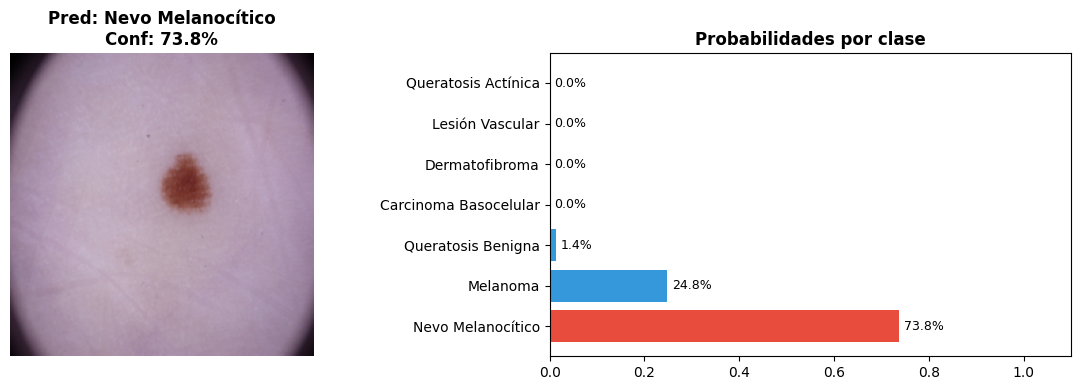


Clase predicha:  nv - Nevo Melanocítico
Confianza:       73.8%


In [20]:
def predict_image(image_path, model=best_model):
    """Predice la clase de una imagen de lesión cutánea y muestra la distribución."""
    prep = tf.keras.applications.resnet50.preprocess_input
    img = Image.open(image_path).convert('RGB').resize(IMG_SIZE)
    arr = prep(np.array(img, dtype=np.float32))
    arr = np.expand_dims(arr, 0)

    proba    = model.predict(arr, verbose=0)[0]
    pred_idx = int(np.argmax(proba))
    pred_cls = CLASS_NAMES[pred_idx]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.imshow(img); ax1.axis('off')
    ax1.set_title(f'Pred: {CLASS_LABELS[pred_cls]}\nConf: {proba[pred_idx]:.1%}',
                  fontweight='bold', fontsize=12)

    sorted_pairs = sorted(zip(CLASS_NAMES, proba), key=lambda x: x[1], reverse=True)
    lbls  = [CLASS_LABELS[c] for c, _ in sorted_pairs]
    vals  = [v for _, v in sorted_pairs]
    cols  = ['#E74C3C' if c == pred_cls else '#3498DB' for c, _ in sorted_pairs]
    bars  = ax2.barh(lbls, vals, color=cols)
    for bar, v in zip(bars, vals):
        ax2.text(v + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.1%}', va='center', fontsize=9)
    ax2.set_xlim(0, 1.1)
    ax2.set_title('Probabilidades por clase', fontweight='bold')
    plt.tight_layout(); plt.show()

    return {'class': pred_cls, 'label': CLASS_LABELS[pred_cls],
            'confidence': float(proba[pred_idx]),
            'probabilities': dict(zip(CLASS_NAMES, proba.tolist()))}


# Ejemplo con una imagen aleatoria del test
sample_path = df_test.sample(1, random_state=0)['path'].values[0]
result = predict_image(sample_path)
print(f"\nClase predicha:  {result['class']} - {result['label']}")
print(f"Confianza:       {result['confidence']:.1%}")